In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

In [7]:
# Load dataset
df = pd.read_csv('/content/international-airline-passengers.csv')
df.columns = ['Month', 'Passengers']
df.dropna(inplace=True)
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df['Passengers'] = df['Passengers'].astype(float)
print(df.tail())

            Passengers
Month                 
1960-08-01       606.0
1960-09-01       508.0
1960-10-01       461.0
1960-11-01       390.0
1960-12-01       432.0


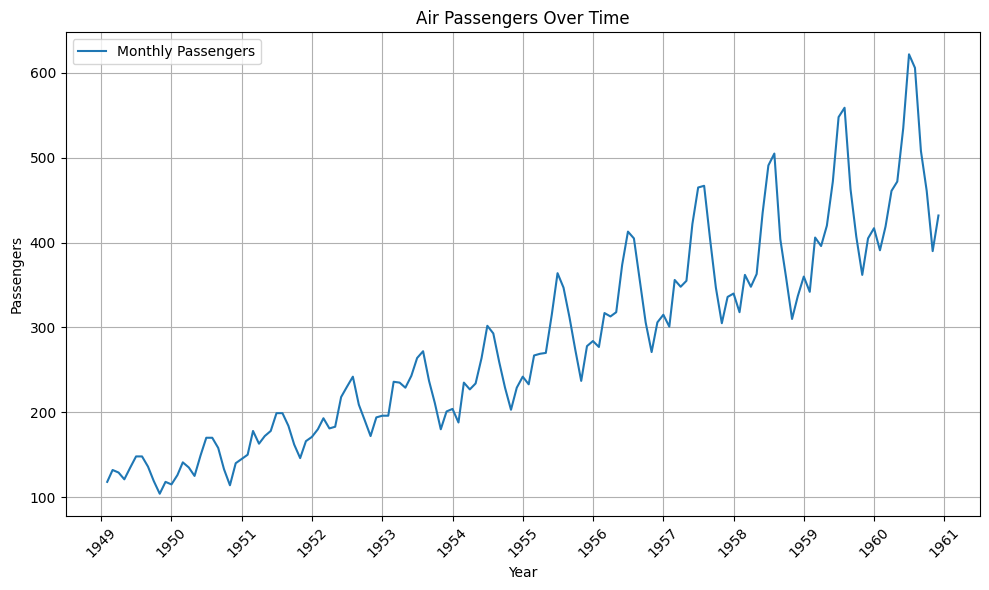

In [10]:
import matplotlib.dates as mdates

# Step 3: Visualize the Original Data with Yearly Ticks
plt.figure(figsize=(10,6))
plt.plot(df.index, df['Passengers'], label='Monthly Passengers')

# Set major ticks to every year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Optional: rotate for clarity
plt.xticks(rotation=45)

plt.title("Air Passengers Over Time")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


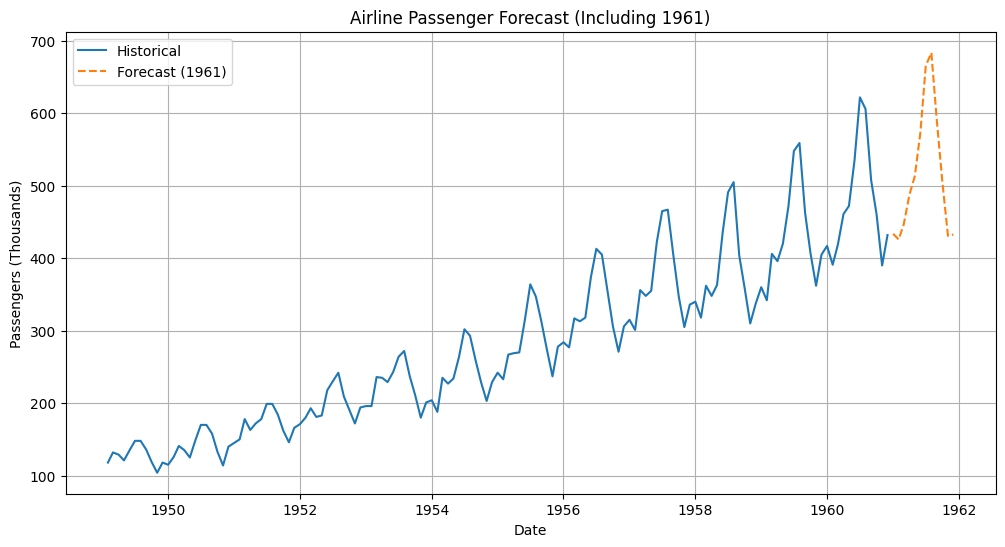

In [16]:

# Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Passengers']])

# Create sequences
SEQ_LENGTH = 12
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Reshape for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

# Build the model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(SEQ_LENGTH, 1)),
    Dense(1)
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Train
model.fit(X, y, epochs=100, verbose=0)

# Forecast future 12 months (1961)
future_preds = []
last_seq = scaled_data[-SEQ_LENGTH:]

for _ in range(12):
    pred = model.predict(last_seq.reshape(1, SEQ_LENGTH, 1), verbose=0)
    future_preds.append(pred[0, 0])
    last_seq = np.append(last_seq[1:], pred).reshape(SEQ_LENGTH, 1)

# Inverse transform
future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1)).flatten()

# Generate future date range
last_date = df.index[-1]
future_dates = pd.date_range(last_date + pd.DateOffset(months=1), periods=12, freq='MS')
future_df = pd.DataFrame({'Month': future_dates, 'Predicted Passengers': future_preds})
future_df.set_index('Month', inplace=True)

# Plot results
plt.figure(figsize=(12, 6))

plt.plot(df.index, df['Passengers'], label='Historical')
plt.plot(future_df.index, future_df['Predicted Passengers'], label='Forecast (1961)', linestyle='--')
plt.title('Airline Passenger Forecast (Including 1961)')
plt.xlabel('Date')
plt.ylabel('Passengers (Thousands)')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict on training data
train_preds = model.predict(X, verbose=0)
train_preds_inv = scaler.inverse_transform(train_preds)
y_inv = scaler.inverse_transform(y.reshape(-1, 1))

# Calculate metrics
mse = mean_squared_error(y_inv, train_preds_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_inv, train_preds_inv)
r2 = r2_score(y_inv, train_preds_inv)

# Print accuracy metrics
print("Model Performance on Training Data:")
print(f"  MSE  = {mse:.2f}")
print(f"  RMSE = {rmse:.2f}")
print(f"  MAE  = {mae:.2f}")
print(f"  R²   = {r2:.4f}")


Model Performance on Training Data:
  MSE  = 365.31
  RMSE = 19.11
  MAE  = 15.51
  R²   = 0.9721
